# Exploring the dataset with IP addresses

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('ip_addresses.csv')

In [8]:
df.head()

,ip address,Latitude,Longitude,Timestamp,suspicious
0,173.198.105.40,35.3696,-119.0105,1736919120,0.0
1,5.165.146.0,56.1089,47.4821,1736919120,0.0
2,70.118.96.132,29.4227,-98.4927,1736919120,0.0
3,173.197.225.168,30.4264,-84.9462,1736919120,0.0
4,210.145.96.0,37.3170,140.3849,1736919120,0.0


In [26]:
df['datetime'] = pd.to_datetime(df['Timestamp'], unit='s')

In [28]:
df.describe()

,Latitude,Longitude,Timestamp,suspicious,datetime
count,2940.000000,2940.000000,2.940000e+03,2940.000000,2940
mean,40.614411,32.544059,1.736919e+09,0.026190,2025-01-15 05:36:56.021088512
min,-41.440100,-157.970300,1.736919e+09,0.000000,2025-01-15 05:32:00
25%,34.693100,-74.002425,1.736919e+09,0.000000,2025-01-15 05:34:24
50%,38.928750,37.826300,1.736919e+09,0.000000,2025-01-15 05:36:50.500000
75%,55.155300,113.722000,1.736920e+09,0.000000,2025-01-15 05:39:28
max,69.400400,158.645600,1.736920e+09,1.000000,2025-01-15 05:42:00
std,14.839804,83.630565,1.753977e+02,0.159729,NaN


### It seems that all data sending happens during 10 minutes

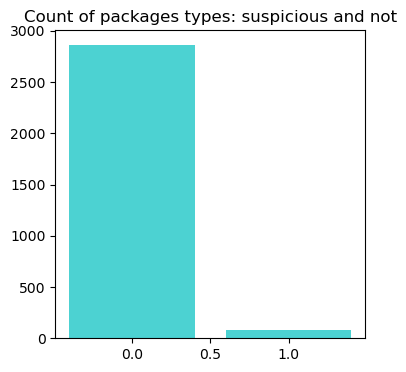

,suspicious,Timestamp
0,0.0,2863
1,1.0,77


In [96]:
sus_flag = df.groupby('suspicious')['Timestamp'].count().reset_index()
plt.figure(figsize=(4,4))
plt.bar(sus_flag['suspicious'], sus_flag['Timestamp'], color = 'c', alpha=0.7)
plt.title('Count of packages types: suspicious and not')
plt.show()
sus_flag

In [54]:
df = df.reset_index()

In [66]:
packages_per_minutes = df.groupby(pd.Grouper(key='datetime', freq='1min'))['index'].count().reset_index()

In [88]:
packages_per_minutes['time'] = packages_per_minutes['datetime'].dt.minute

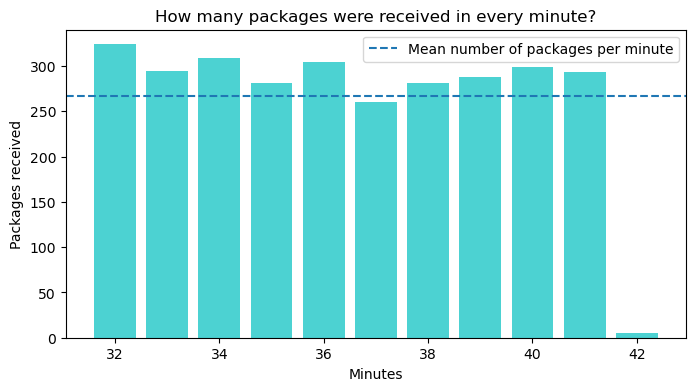

In [104]:
plt.figure(figsize=(8,4))
plt.bar(packages_per_minutes['time'], packages_per_minutes['index'], color='c', alpha=0.7)
plt.axhline(packages_per_minutes['index'].mean(), linestyle='--', label='Mean number of packages per minute')
plt.title('How many packages were received in every minute?')
plt.xlabel("Minutes")
plt.ylabel("Packages received")
plt.legend()
plt.show()

## This EDA helped to understand data organization in the provided dataset: what is the average number of packages reseived, what is the period of time is presented.